# Density NN Architecture Experiments

This notebook explores neural network architectures for Minecraft cell-level density prediction using the available training data. We will load the data, preprocess it, define and train models, evaluate their performance, and experiment with different architectures.

## 1. Load Training Data

Load the training data from the repository. The expected dataset is in `noise_training_data/` at the repository root. If `stage1_density_data.npz` is not present, the notebook will fall back to the available pickle dataset and explain the expected format.

In [ ]:
import numpy as np
import torch
from pathlib import Path

# Training data generated by:  python scripts/convert_noise_dumps_to_npz.py
# Source: 81 real Minecraft chunks from VoxelTree/tools/fabric-server/runtime/noise_dumps/
# Run /dumpnoise in-game to generate more (see LODiffusion Fabric mod).
#
# Input channels (7):
#   0 continents, 1 erosion, 2 ridges, 3 depth,
#   4 temperature, 5 vegetation  -- all 4x4 surface values broadcast across Y
#   6 y_norm  -- cell-centre Y normalised to [-1, +1]
# Output (1): final_density (positive = solid, negative = air)

DATA_PATH = 'noise_training_data/phase_1a_data.npz'
npz_path = noise_data / "stage1_density_data.npz"
pkl_path = noise_data / "legacy_heightmap.pkl"
    f"Missing: {DATA_PATH}\n"
    "Generate it with: python scripts/convert_noise_dumps_to_npz.py"
)

data = np.load(DATA_PATH)
inputs  = data['inputs']   # (N, 4, 48, 4, 7)
outputs = data['outputs']  # (N, 4, 48, 4, 1)

print('Inputs  shape:', inputs.shape,  '-- 7 real noise router features')
print('Outputs shape:', outputs.shape, '-- real Minecraft final_density')
print(f'Chunks: {inputs.shape[0]}  |  solid fraction: {(outputs > 0).mean():.3f}')


Inputs  shape: (81, 4, 48, 4, 7) -- 7 real noise router features
Outputs shape: (81, 4, 48, 4, 1) -- real Minecraft final_density
Chunks: 81  |  solid fraction: 0.319


In [3]:
# Sanity-check: solid fraction should be ~1 near bedrock (Y=-60) and 0 at high altitudes
print('Y-level solid fractions (should drop off at high Y):')
dens = outputs.reshape(outputs.shape[0], 4, 48, 4)  # (N, 4, 48, 4)
for cy in [0, 6, 12, 18, 24, 30, 36, 42, 47]:
    y_world = -64 + cy * 8 + 4
    frac = (dens[:, :, cy, :] > 0).mean()
    print(f'  cy={cy:2d}  Y={y_world:4d}  solid={frac:.3f}')


Y-level solid fractions (should drop off at high Y):
  cy= 0  Y= -60  solid=0.975
  cy= 6  Y= -12  solid=0.869
  cy=12  Y=  36  solid=0.931
  cy=18  Y=  84  solid=0.025
  cy=24  Y= 132  solid=0.000
  cy=30  Y= 180  solid=0.000
  cy=36  Y= 228  solid=0.000
  cy=42  Y= 276  solid=0.000
  cy=47  Y= 316  solid=0.000


## 2. Preprocess Data

Prepare the data for training: normalize features, split into training and validation sets.

In [4]:
from sklearn.model_selection import train_test_split

# Normalize input features to [-1, 1] (if not already)
inputs_norm = inputs.astype(np.float32)
outputs_norm = outputs.astype(np.float32)

# Flatten batch dimension for splitting
N = inputs.shape[0]
X = inputs_norm.reshape(N, -1)
Y = outputs_norm.reshape(N, -1)

X_train, X_val, Y_train, Y_val = train_test_split(X, Y, test_size=0.2, random_state=42)

print('Training samples:', X_train.shape[0])
print('Validation samples:', X_val.shape[0])

Training samples: 64
Validation samples: 17


## 3. Define Neural Network Architecture

Use PyTorch to define a simple Conv3D-based neural network for density prediction.

In [5]:
import torch.nn as nn

INPUT_CH  = 7   # continents, erosion, ridges, depth, temperature, vegetation, y_norm
OUTPUT_CH = 1   # final_density

class SimpleDensityNet(nn.Module):
    """3-layer Conv3D baseline. input shape: (N, C_in, 4, 48, 4)."""
    def __init__(self, input_channels=INPUT_CH, output_channels=OUTPUT_CH):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(input_channels, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv3d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv3d(64, output_channels, kernel_size=3, padding=1),
        )

    def forward(self, x):
        return self.net(x)


class DeeperDensityNet(nn.Module):
    """5-layer Conv3D with BatchNorm -- swap in below to compare."""
    def __init__(self, input_channels=INPUT_CH, output_channels=OUTPUT_CH):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(input_channels, 32, 3, padding=1), nn.BatchNorm3d(32),  nn.ReLU(),
            nn.Conv3d(32, 64,          3, padding=1), nn.BatchNorm3d(64),  nn.ReLU(),
            nn.Conv3d(64, 128,         3, padding=1), nn.BatchNorm3d(128), nn.ReLU(),
            nn.Conv3d(128, 64,         3, padding=1), nn.BatchNorm3d(64),  nn.ReLU(),
            nn.Conv3d(64, output_channels, 3, padding=1),
        )

    def forward(self, x):
        return self.net(x)


# --- pick architecture here ---
model = SimpleDensityNet()
# model = DeeperDensityNet()
print(model)
param_count = sum(p.numel() for p in model.parameters())
print(f'Parameters: {param_count:,}')


SimpleDensityNet(
  (net): Sequential(
    (0): Conv3d(7, 32, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (1): ReLU()
    (2): Conv3d(32, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
    (3): ReLU()
    (4): Conv3d(64, 1, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1))
  )
)
Parameters: 63,169


## 4. Compile the Model

Set up the optimizer, loss function, and metrics for training.

In [6]:
import torch.optim as optim

# Move model to device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# Loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print('Using device:', device)

Using device: cpu


## 5. Train the Model

Train the neural network on the training data and monitor performance on the validation set.

In [7]:
# Reshape -> PyTorch convention (N, C, X, Y, Z)
X_train_tensor = torch.from_numpy(X_train.reshape(-1, 4, 48, 4, INPUT_CH)).permute(0, 4, 1, 2, 3).to(device)
Y_train_tensor = torch.from_numpy(Y_train.reshape(-1, 4, 48, 4, OUTPUT_CH)).permute(0, 4, 1, 2, 3).to(device)
X_val_tensor   = torch.from_numpy(X_val.reshape(  -1, 4, 48, 4, INPUT_CH)).permute(0, 4, 1, 2, 3).to(device)
Y_val_tensor   = torch.from_numpy(Y_val.reshape(  -1, 4, 48, 4, OUTPUT_CH)).permute(0, 4, 1, 2, 3).to(device)

num_epochs = 10
batch_size = 8

train_losses = []
val_losses   = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    n_batches = 0
    for i in range(0, X_train_tensor.shape[0], batch_size):
        xb = X_train_tensor[i:i+batch_size]
        yb = Y_train_tensor[i:i+batch_size]
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
        n_batches += 1
    train_losses.append(epoch_loss / max(n_batches, 1))

    model.eval()
    with torch.no_grad():
        val_loss = 0
        nv = 0
        for i in range(0, X_val_tensor.shape[0], batch_size):
            xb = X_val_tensor[i:i+batch_size]
            yb = Y_val_tensor[i:i+batch_size]
            pred = model(xb)
            val_loss += criterion(pred, yb).item()
            nv += 1
        val_losses.append(val_loss / max(nv, 1))

    print(f'Epoch {epoch+1:2d}/{num_epochs} - train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}')


Epoch  1/10 - train=0.04785  val=0.02985
Epoch  2/10 - train=0.01974  val=0.01174
Epoch  3/10 - train=0.01173  val=0.00965
Epoch  4/10 - train=0.00899  val=0.00780
Epoch  5/10 - train=0.00729  val=0.00656
Epoch  6/10 - train=0.00614  val=0.00547
Epoch  7/10 - train=0.00527  val=0.00479
Epoch  8/10 - train=0.00474  val=0.00439
Epoch  9/10 - train=0.00431  val=0.00396
Epoch 10/10 - train=0.00397  val=0.00386


## 6. Evaluate Model Performance

Assess the trained model's performance using mean squared error and visualize predictions vs ground truth.

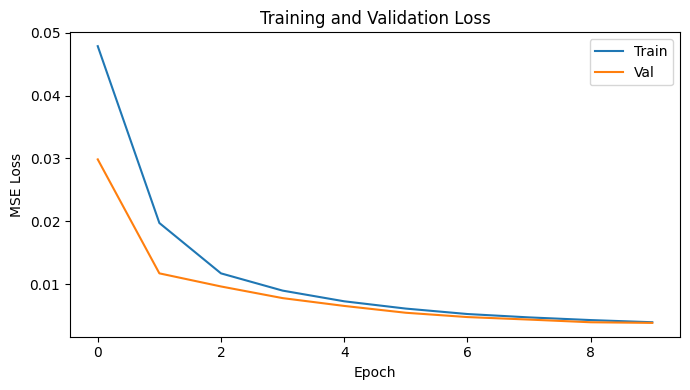

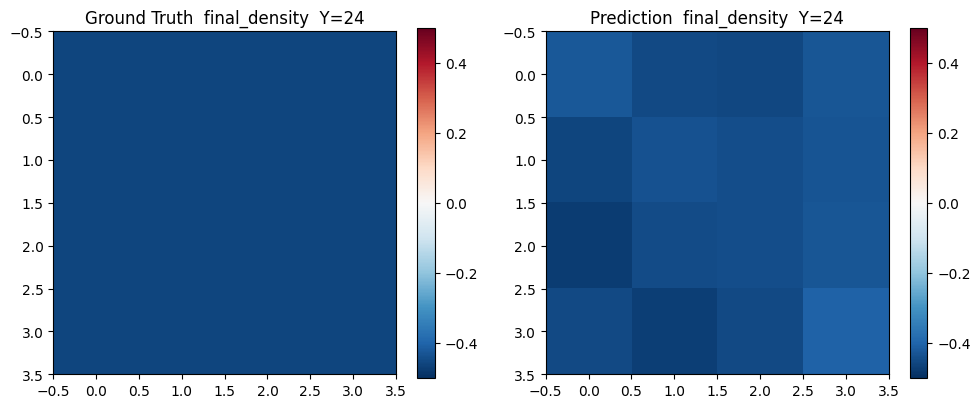

Sign accuracy (solid/air correct): 0.932
MSE on this sample: 0.006754


In [8]:
import matplotlib.pyplot as plt

# Loss curves
plt.figure(figsize=(7, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Epoch'); plt.ylabel('MSE Loss')
plt.legend(); plt.title('Training and Validation Loss')
plt.tight_layout(); plt.show()

# Density cross-sections for a random validation sample
model.eval()
with torch.no_grad():
    idx  = np.random.randint(0, X_val_tensor.shape[0])
    xb   = X_val_tensor[idx:idx+1]
    yb   = Y_val_tensor[idx:idx+1]
    pred = model(xb).cpu().numpy()   # (1, 1, 4, 48, 4)
    gt   = yb.cpu().numpy()          # (1, 1, 4, 48, 4)

# Y-slice at cy=24 (~Y=124, mid-column)
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
kw = dict(cmap='RdBu_r', vmin=-0.5, vmax=0.5)
im = axes[0].imshow(gt[0, 0, :, 24, :].T, **kw)   # (4,4) -> X on x, Z on y
axes[0].set_title('Ground Truth  final_density  Y=24')
plt.colorbar(im, ax=axes[0])
im = axes[1].imshow(pred[0, 0, :, 24, :].T, **kw)
axes[1].set_title('Prediction  final_density  Y=24')
plt.colorbar(im, ax=axes[1])
plt.tight_layout(); plt.show()

# Solid/air sign accuracy
sign_acc = (np.sign(pred) == np.sign(gt)).mean()
print(f'Sign accuracy (solid/air correct): {sign_acc:.3f}')
print(f'MSE on this sample: {((pred - gt)**2).mean():.6f}')


## 7. Experiment with Different Architectures

Modify the neural network architecture (layers, activation functions, etc.) and compare performance across experiments. Try adding more layers, changing activation functions, or using batch normalization.